# Linear discriminant analysis

> A serious attempt at all the assignments is mandatory to grant access to the final exam. Refer to the course manual for more details (section *Overview* on Brightspace). 

> Please add today's topic to your knowledge graph.

**Learning goals:**
- Understand and be able to implement and use LDA;
- Understand assumptions and limitations of LDA;
- Be able to provide solution to common issues of LDA.

**Solutions file:**

For this assignment, a solutions file will be released after the deadline.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import mne
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.metrics import accuracy_score

## Exercise 1: train LDA
In the first exercise, you will implement LDA from scratch using plain numpy. We will later train and test it with the Iris dataset, and compare it to the implementation from the "sklearn" library.
1. Provide the equations to train the weights and bias of LDA in LaTeX. (You can use LaTeX in Markdown by surrounding your formula with \$\$); 
1. Write the function `train_lda(X, y)` that accepts the data $X$ of dimensionality $N_{samples} \times D_{features}$ and the labels $y$, a vector of $N_{samples}$ containing integer class labels. The function should output the weights and bias. Note, we assume a binary classification problem.

$\textbf{S}_k = \frac{1}{N_k - 1} \sum_{n \in C_k}(\textbf{x}_n-\textbf{m}_k)(\textbf{x}_n-\textbf{m}_k)^T$

$\textbf{S}_W = \frac{1}{2} (\textbf{S}_1 + \textbf{S}_2)$

$\textbf{w} = \textbf{S}_W^{-1} (\textbf{m}_2 - \textbf{m}_1)$

$b = -\frac{1}{2}\textbf{w}^T (\textbf{m}_1 + \textbf{m}_2)$


In [2]:
def train_lda(X, y):
    X0 = X[y == 1]
    X1 = X[y == 2]
    
    m1 = np.mean(X0, axis=0)
    m2 = np.mean(X1, axis=0)

    S1 = np.matmul(np.transpose(X0 - m1), X0 - m1)/(len(X0)-1)
    S2 = np.matmul(np.transpose(X1 - m2), X1 - m2)/(len(X1)-1)
    S_w = 0.5 * (S1 + S2)
    
    weights = np.matmul(np.linalg.inv(S_w), m2 - m1)
    bias = -0.5 * np.matmul(np.transpose(weights), m1 + m2)
    return weights, bias

## Exercise 2: apply LDA
The next step is to implement the routine to apply LDA to new data (i.e., validation/test data). 
1. Provide the equations to apply LDA to new data using the weights and bias in LaTeX;
1. Write a function `apply_lda(X, weights, bias)` that accepts the weights and bias to classify data $X$ of dimensionality $N_{samples} \times D_{features}$. It should output predicted labels, one for each sample in $X$.

$f(\textbf{x}) = \textbf{w}^T \textbf{x} + b$


In [3]:
def apply_lda(X, weights, bias):
    f_x = np.matmul(X, np.transpose(weights)) + bias

    y = np.ndarray
    y = np.where(f_x >= 0, 2, 1)  # where condition correct yield x otherwise y
    return y

## Exercise 3: classify the Iris dataset
Now it is time to test your implementation. For this we use the well-known Iris dataset. We provide some code below to download this data from the "pandas" library using `datasets.load_iris()`. Many more standard datasets exist there for quick testing and benchmarking. Pandas uses so called 'dataframes' that are easily interpreted by "seaborn", that has a nice built-in function `pairplot()` to visualize the features. For this assignment, we will restrict the dataset to only two classes.

Your tasks:
1. Train and apply your LDA and compute the classification accuracy.
1. Train and apply the LDA from sklearn (`LDA()`), and compare its classification accuracy to yours. 

Number of features:  4
Number of train examples:  80
Number of valid examples:  20


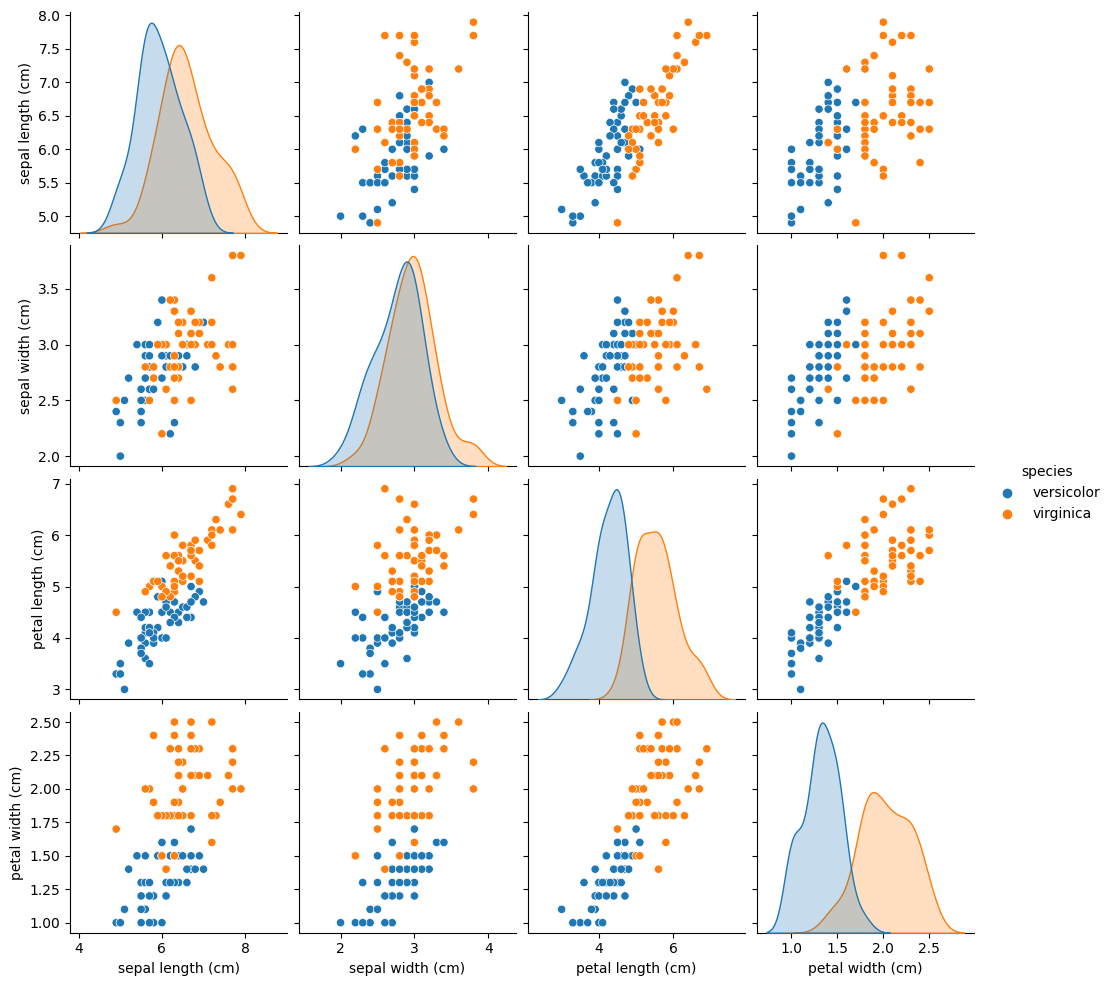

In [4]:
# Load Iris dataset and select 2 classes
iris = datasets.load_iris()
labels = [1, 2]
idx = np.logical_or(iris.target == labels[0], iris.target == labels[1])
iris.data = iris.data[idx, :]
iris.target = iris.target[idx]

# Make a pandas dataframe
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target_names[iris.target]

# Plot data
sns.pairplot(df, hue="species")

# Split data
X_train, X_valid, y_train, y_valid = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)
print("Number of features: ", X_train.shape[1])
print("Number of train examples: ", X_train.shape[0])
print("Number of valid examples: ", X_valid.shape[0])


In [5]:
w, b = train_lda(X_train, y_train)
print(f"Weights {w}\nBias {b}\n")
lda1 = apply_lda(X_valid, w, b)  # labels - results
print("Predicted labels:", lda1)

score = np.sum(lda1 == y_valid)/len(lda1) * 100
print("Our LDA accuracy score: {:.2f}%".format(score))

lda2 = LDA()
lda2.fit(X_train, y_train)
score = lda2.score(X_valid,y_valid) * 100
print("Sklearn LDA accuracy score: {:.2f}%".format(score))

Weights [-3.69930365 -8.7386991   8.01658502 15.47895067]
Bias -17.03847031566252

Predicted labels: [1 2 2 1 1 1 2 2 1 1 2 1 2 2 2 1 2 2 1 1]
Our LDA accuracy score: 80.00%
Sklearn LDA accuracy score: 80.00%


## Exercise 4: preprocess features
Sometimes, some of the features clearly violate the **linear separability** assumption made by LDA. In that case, features can be pre-processed by applying a given function to each feature, which yields a Generalized Linear Discriminant analysis:
$$
y = \sum_{i=1}^{D} w_i\, f_i(\mathbf{x}_i)
$$
We provide a dataset below, please inspect it.

Your tasks:
1. Which LDA assumption(s) are violated by the provided dataset?
1. In which way can the feature(s) be preprocessed in order to improve the performance? Hint: Think of polynomials, trigonometric functions, logarithms, exponential functions, etc.;
1. Apply your preprocessing idea to the data;
1. Visualize the preprocessed data;
1. Classify the preprocessed data using sklearn's `LDA()`. Did it improve?

Accuracy validation: 65.00%


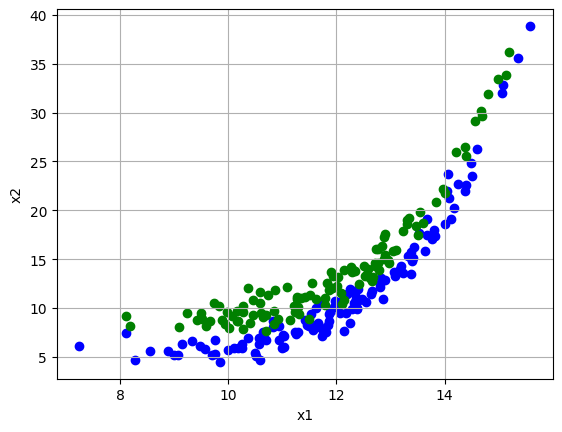

In [6]:
# (1) load data
ds_data = 'data/non-lin_train.data'
ds_labels ='data/non-lin_train.labels'
X = np.loadtxt(ds_data)
y = np.loadtxt(ds_labels)
n_samples = y.size
# print(n_samples)

# (2) split into training and validation
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# (3) scatter-plot data with corresponding labels
plt.figure()
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1] ,color='b')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='g')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid()

# (4) classify un-processed data
clf = LDA()
clf.fit(X_train, y_train)
score = clf.score(X_valid, y_valid) * 100
print('Accuracy validation: {:.2f}%'.format(score))


By looking at the visualization of the training data above, we can see that the linear seperability assumption is violated. 

[[ 2.59078957  8.83332768]
 [ 8.83332768 41.36378142]]
[[ 2.72142221 10.98981573]
 [10.98981573 66.32067555]]
By visualizing the covariance matrices, we can see that the covariances are not equal. 

We preprocess the feature(s) to improve the performance by taking the logarithm of the data. 



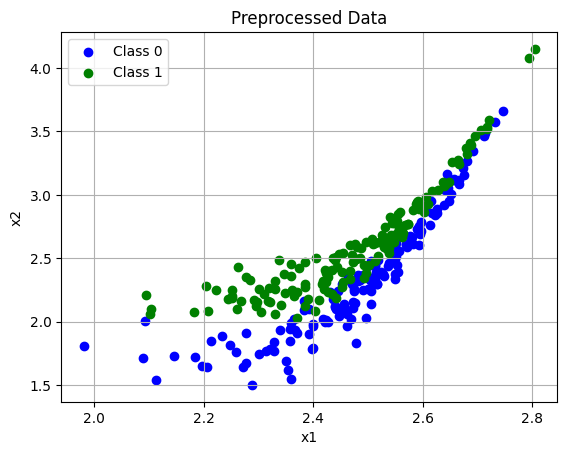

Accuracy validation: 75.00%


In [7]:
# Answer here
# 1. Which LDA assumption(s) are violated by the provided dataset?
print("By looking at the visualization of the training data above, we can see that the linear seperability assumption is violated. \n")

cov0 = np.cov(X[y==0], rowvar=False)
cov1 = np.cov(X[y==1], rowvar=False)
print(cov0)
print(cov1)
print("By visualizing the covariance matrices, we can see that the covariances are not equal. \n")

# 2. In which way can the feature(s) be preprocessed in order to improve the performance? 
print("We preprocess the feature(s) to improve the performance by taking the logarithm of the data. \n")

# 3. Apply your preprocessing idea to the data;
X_preprocessed = np.log(X)

# 4. Visualize the preprocessed data;
plt.scatter(X_preprocessed[y == 0, 0], X_preprocessed[y == 0, 1], c='b', label='Class 0')
plt.scatter(X_preprocessed[y == 1, 0], X_preprocessed[y == 1, 1], c='g', label='Class 1')
plt.title('Preprocessed Data')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid()
plt.show()

# 5. Classify preprocessed data
X_train, X_valid, y_train, y_valid = train_test_split(X_preprocessed, y, test_size=0.2, random_state=42)
clf = LDA()
clf.fit(X_train, y_train)
score = clf.score(X_valid, y_valid) * 100
print('Accuracy validation: {:.2f}%'.format(score))


## (Optional) Exercise 5: extract features
Below we provide another dataset. There appears to be some exploitable structure in this data, but the LDA is not directly able to capture this.

Your tasks:
1. Which LDA assumption(s) are violated by the provided dataset?
1. In what way can the existing features be combined in order to get a proper dataset? **Hint:** Try to think of it in a 3D way: How would you add another dimension such that the 2 classes can be separated?
1. Implement your additional feature that combines the existing features;
1. Visualize the new feature using a histogram;
1. Calculate the performance of LDA using this additional feature and see if you can improve upon the performance.

Accuracy validation: 26.67%


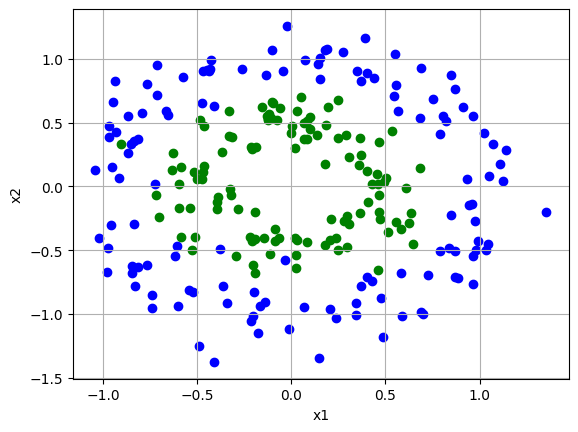

In [8]:
# (1) load data
ds_data = 'data/circles_train.data'
ds_labels ='data/circles_train.labels'
X = np.loadtxt(ds_data)
y = np.loadtxt(ds_labels)
n_samples = len(y)

# (2) split into training and validation
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# (3) scatter-plot data with corresponding labels
plt.figure()
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1] ,color='b')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='g')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid()

# (4) classify un-processed data
clf = LDA()
clf.fit(X_train, y_train)
score = clf.score(X_valid, y_valid) * 100
print('Accuracy validation: {:.2f}%'.format(score))


By looking at the visualization of the training data above, we can see that the linear seperability assumption is violated. 

[[ 0.50153545 -0.03285708]
 [-0.03285708  0.58154334]]
[[ 0.14870945 -0.00599771]
 [-0.00599771  0.14165735]]
By visualizing the covariance matrices, we can see that the covariances are not equal. 

We preprocess the feature(s) to improve the performance by mapping the data into higher-dimensional space, using the kernel trick from https://www.geeksforgeeks.org/machine-learning/linear-separability-with-python/. 



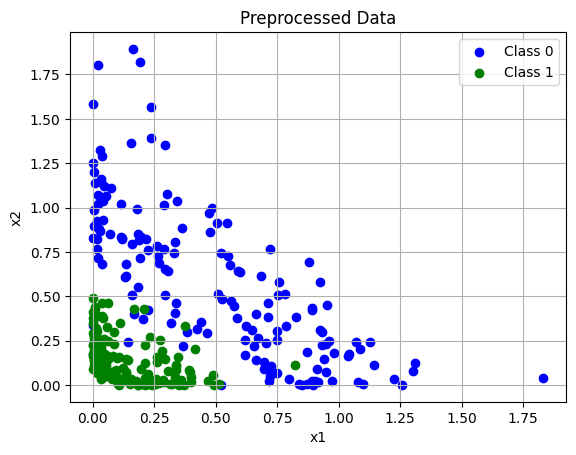

Accuracy validation: 96.67%


In [9]:
# Answer here
# 1. Which LDA assumption(s) are violated by the provided dataset?
print("By looking at the visualization of the training data above, we can see that the linear seperability assumption is violated. \n")

cov0 = np.cov(X[y==0], rowvar=False)
cov1 = np.cov(X[y==1], rowvar=False)
print(cov0)
print(cov1)
print("By visualizing the covariance matrices, we can see that the covariances are not equal. \n")

# 2. In which way can the feature(s) be preprocessed in order to improve the performance? 
print("We preprocess the feature(s) to improve the performance by mapping the data into higher-dimensional space, using the kernel trick from https://www.geeksforgeeks.org/machine-learning/linear-separability-with-python/. \n")

# 3. Apply your preprocessing idea to the data;
X_preprocessed = np.vstack((X[:, 0]**2, X[:, 1]**2)).T

# 4. Visualize the preprocessed data;
plt.scatter(X_preprocessed[y == 0, 0], X_preprocessed[y == 0, 1], c='b', label='Class 0')
plt.scatter(X_preprocessed[y == 1, 0], X_preprocessed[y == 1, 1], c='g', label='Class 1')
plt.title('Preprocessed Data')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid()
plt.show()

# 5. Classify preprocessed data
X_train, X_valid, y_train, y_valid = train_test_split(X_preprocessed, y, test_size=0.2, random_state=42)
clf = LDA()
clf.fit(X_train, y_train)
score = clf.score(X_valid, y_valid) * 100
print('Accuracy validation: {:.2f}%'.format(score))


## (Optional) Exercise 6: other LDA-like algorithms
Below we provide another dataset, that again is problematic for standard LDA.

Your tasks:
1. What LDA assumption(s) are violated by the next dataset?
1. What would be an optimal decision boundary? Optional: Find out which method would provide an optimal decision boundary. **Hint:** It is slightly more general than the LDA algorithm;
1. Implement this improvement and verify whether it indeed improves classification of this dataset.

Accuracy validation: 88.33%


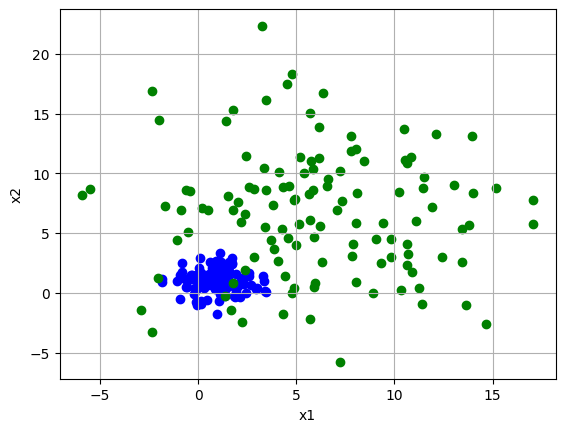

In [10]:
# (1) load data
ds_data = 'data/unbalanced_train.data'
ds_labels ='data/unbalanced_train.labels'
X = np.loadtxt(ds_data)
y = np.loadtxt(ds_labels)
n_samples = len(y)

# (2) split into training and validation
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# (3) scatter-plot data with corresponding labels
plt.figure()
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1] ,color='b')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='g')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid()

# (4) classify un-processed data
clf = LDA()
clf.fit(X_train, y_train)
score = clf.score(X_valid, y_valid) * 100
print('Accuracy validation: {:.2f}%'.format(score))


In [11]:
# Answer here
# 1. Which LDA assumption(s) are violated by the provided dataset?
print("By looking at the visualization of the training data above, we can see that the linear seperability assumption is violated. \n")

cov0 = np.cov(X[y==0], rowvar=False)
cov1 = np.cov(X[y==1], rowvar=False)
print(cov0)
print(cov1)
print("By visualizing the covariance matrices, we can see that the covariances of the classes are not equal and are far apart from each other. \n")

# 2. What would be an optimal decision boundary? Optional: Find out which method would provide an optimal decision boundary.
print("We can find the optimal decision boundary using QDA") 

# 3. classify un-processed data with QDA
clf = QDA()
clf.fit(X_train, y_train)
score = clf.score(X_valid, y_valid) * 100
print('Accuracy validation: {:.2f}%'.format(score))

By looking at the visualization of the training data above, we can see that the linear seperability assumption is violated. 

[[ 1.25153651 -0.01095006]
 [-0.01095006  0.87217804]]
[[23.50565671 -0.56150476]
 [-0.56150476 29.85887442]]
By visualizing the covariance matrices, we can see that the covariances of the classes are not equal and are far apart from each other. 

We can find the optimal decision boundary using QDA
Accuracy validation: 95.00%


## Exercise 7: Apply LDA to EEG data
Now you will try a simple decoding on EEG data. For this, we will make use of one of mne's standard data sets, which you will already know from assignment 1 - but we just load a version resampled to `30Hz`.

The data we load is the so called `raw` data, which we will slice to epochs depending on markers relative to the start of the recording of the raw file. Each epoch should range from -200ms to +800ms around the epoch start marker. Of course you could just make use of `mne`'s build in functions. But for now please operate on the plain numpy array of the raw data. This will ensure, that you are aware of the notion of `epoch` vs `raw` data.

We need this epoch structure as EEG experiments are usually designed to produce one label per epoch. Hence an epoch is our basic "record" unit.

**Question**:
1. Slice the raw data to epochs.
1. After step 1. your data should be in shape of [n_epochs x n_channels x n_times]. The next step is to stack the channel dimension in order to be able to use the data in a standard `sklearn` LDA classifier. Transform the epoched data to [n_epochs x n_channels * n_times]
1. Use the first 100 epochs to train an LDA classifier and report the accuracy of classifying
   the left over epochs as test set.
1. *Optional*: Why will the classifier just perform very poorly in terms of accuracy?

In [ ]:
# Prepare data and the classifier
# the raw data
raw = mne.io.read_raw('./data/sample_audvis_rsampl30Hz_raw.fif')
Xraw = raw.get_data()
print(Xraw.shape)  # (channels, samples) 

# markers == labels (not always the case that all markers are labels, but its valid here)
mrks = np.load('./data/events.npy', allow_pickle=True)  # (143, 2)
mp = {1: 'left_auditory', 2: 'right_auditory'}
mrks_t = mrks[:, 0]  # (143,) column vector

print(25*'-', "Marker info", 25*'-',)
print(mrks_t[:5])
print(mrks[:5, 1]) # mrks[:, 1] is labels of 1 or 2
y = [mp[e] for e in mrks[:, 1]]
print("{} \n {}".format(y[:5], 50*'-')) 

# the classifier
clf = LDA()


# 1. Slice the raw data to epochs.
epochs_list = []
for i in mrks_t:
    start = int(i + (-0.2 * 30))  # x sampling rate 30 Hz 
    end = int(i + (0.8 * 30))  # to transform to samples
    if start >= 0 and end <= len(Xraw[1]):
        epoch = Xraw[:, start:end]
        epochs_list.append(epoch)
epochs = np.array(epochs_list) # (143, 59, 30)

# 2. Transform the epoched data to [n_epochs x n_channels * n_times]
X = epochs.reshape(epochs.shape[0], epochs.shape[1] * epochs.shape[2]) # (143, 1770)

# 3. Use the first 100 epochs to train an LDA classifier and report the accuracy of classifying the left over epochs as test set.
X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=100, shuffle=False)
clf.fit(X_train, y_train)
score = clf.score(X_valid, y_valid) * 100
print('Accuracy validation: {:.2f}%'.format(score))

# 4. Optional: Why will the classifier just perform very poorly in terms of accuracy?
print("The classifier performs very poorly because the data is not pre-processed at all.")

Opening raw data file ./data/sample_audvis_rsampl30Hz_raw.fif...
    Read a total of 1 projection items:
        Average EEG reference (1 x 60)  idle
    Range : 1289 ... 9619 =     42.967 ...   320.633 secs
Ready.
(59, 8331)
------------------------- Marker info -------------------------
[46.56666666666667 47.9 49.36666666666667 50.7 52.0]
[2 1 2 1 2]
['right_auditory', 'left_auditory', 'right_auditory', 'left_auditory', 'right_auditory'] 
 --------------------------------------------------
Accuracy validation: 48.84%
The classifier performs very poorly because the data is not pre-processed at all.


## Exercise 0: Who did what?
Please provide a short description on who contributed what to your submission.

> Laurens Sloothaak & Jeroen Droog - Exercise 1,2,3
> 
> Jeroen Droog - Exercise 4, 5, 6, 7